# Verify `binary_edge_target_from_affinity()` on Binary vs Distance Labels

이 노트북은 [connect_loss.py](../connect_loss.py)의 `binary_edge_target_from_affinity()`가 실제 CHASE 샘플에서
의도한 edge target을 계산하는지 확인한다.

검증 포인트:
- 함수 출력이 수식 `((sum_conn < conn_num) & (sum_conn > 0))`와 정확히 일치하는가
- `binary` GT에서 만든 edge와 `dist_target > 0` mask에서 만든 edge가 얼마나 비슷한가
- `binary` GT와 `dist_target > 0` mask의 차이가 edge target 차이에 어떻게 반영되는가

주의:
- 현재 `connectivity_matrix()` 구현은 CUDA를 전제로 하므로 GPU 환경에서 실행한다.
- `binary` GT와 `dist_target > 0` mask가 완전히 같지 않을 수 있으므로, edge mismatch는 함수 오류와 별개로 GT 차이를 반영할 수 있다.


In [3]:
try:
    import autorootcwd  # type: ignore
except Exception:
    pass

from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
import torch

from data_loader.GetDataset_CHASE import MyDataset_CHASE
from connect_loss import connect_loss, connectivity_matrix

if not torch.cuda.is_available():
    raise RuntimeError('This notebook requires CUDA because connectivity_matrix() currently allocates CUDA tensors internally.')

DEVICE = torch.device('cuda')
args = SimpleNamespace(num_class=1, dataset='chase')
real_root = 'data/chase'
ids = ['01', '02', '03']

binary_set = MyDataset_CHASE(args=args, train_root=real_root, pat_ls=ids, mode='test', label_mode='binary')
dist_set = MyDataset_CHASE(args=args, train_root=real_root, pat_ls=ids, mode='test', label_mode='dist')
_, y0, _ = binary_set[0]
H, W = y0.shape[-2:]

hori = torch.zeros((1, 1, W, W), dtype=torch.float32, device=DEVICE)
vert = torch.zeros((1, 1, H, H), dtype=torch.float32, device=DEVICE)
for i in range(W - 1):
    hori[:, :, i, i + 1] = 1.0
for j in range(H - 1):
    vert[:, :, j, j + 1] = 1.0

loss_fn = connect_loss(args, hori, vert, label_mode='binary', conn_num=8, sigma=2.0)


def manual_edge_from_affinity(affinity_target, conn_num=8):
    class_conn = affinity_target.view(affinity_target.shape[0], 1, conn_num, affinity_target.shape[2], affinity_target.shape[3])
    sum_conn = class_conn.sum(dim=2)
    return torch.where(
        (sum_conn < conn_num) & (sum_conn > 0),
        torch.full_like(sum_conn, 1),
        torch.full_like(sum_conn, 0),
    )

Function vs manual formula:
sample    source  edge_fn_ratio  edge_manual_ratio  fn_vs_manual_mismatch  fn_equals_manual
   01L binary_gt       0.026462           0.026462                    0.0              True
   01L dist_mask       0.028270           0.028270                    0.0              True
   01R binary_gt       0.027793           0.027793                    0.0              True
   01R dist_mask       0.029098           0.029098                    0.0              True
   02L binary_gt       0.029615           0.029615                    0.0              True
   02L dist_mask       0.032321           0.032321                    0.0              True
   02R binary_gt       0.030945           0.030945                    0.0              True
   02R dist_mask       0.033315           0.033315                    0.0              True
   03L binary_gt       0.031226           0.031226                    0.0              True
   03L dist_mask       0.033420           0.033420  

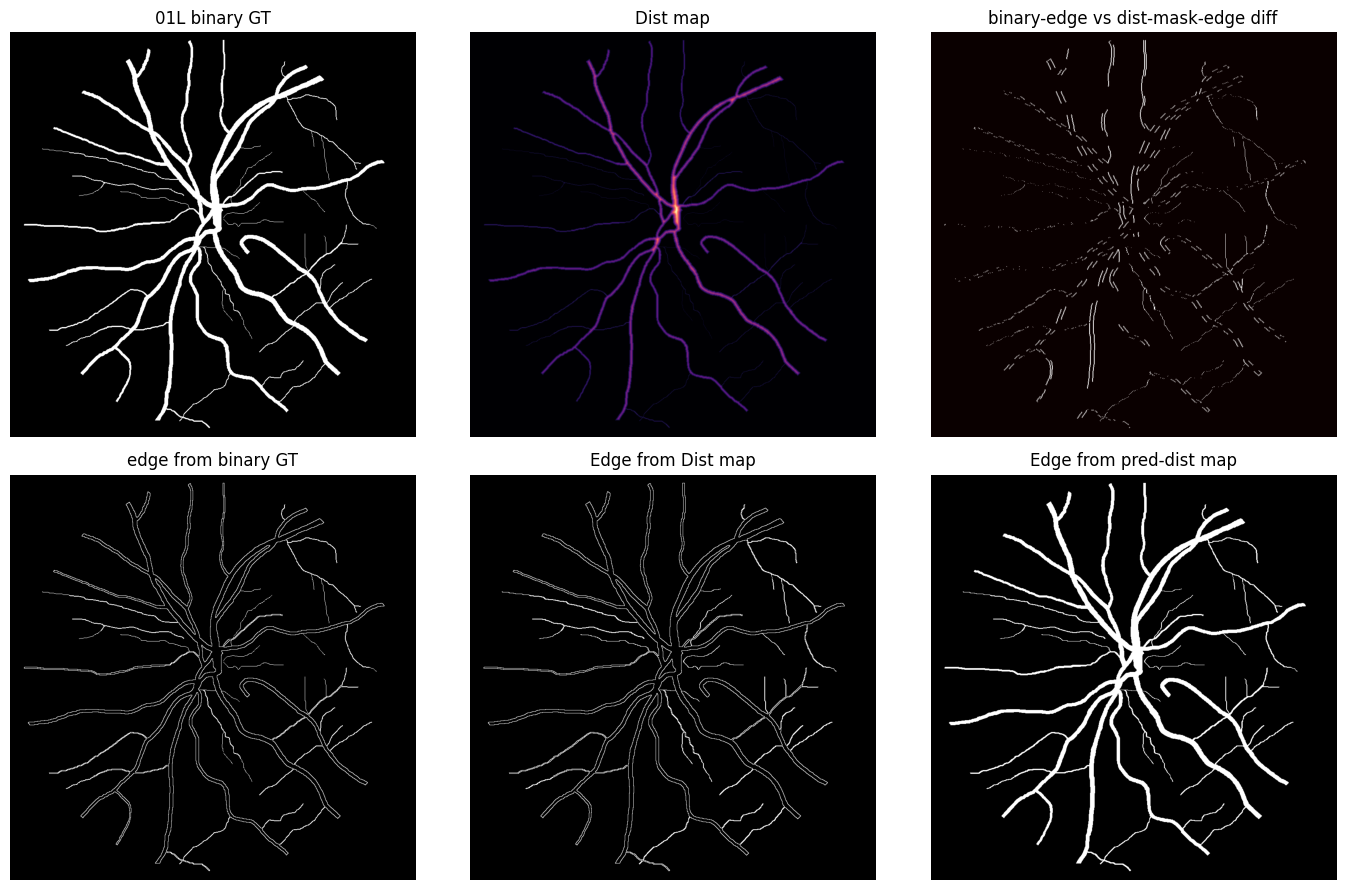

In [4]:
manual_rows = []
compare_rows = []
first_visual = None

for idx in range(min(6, len(binary_set), len(dist_set))):
    _, binary_target, name_b = binary_set[idx]
    _, dist_target, name_d = dist_set[idx]
    assert name_b == name_d

    binary_target = binary_target.unsqueeze(0).to(DEVICE)
    dist_target = dist_target.unsqueeze(0).to(DEVICE)
    dist_mask = (dist_target > 0).float()

    binary_aff = connectivity_matrix(binary_target, 1)
    dist_mask_aff = connectivity_matrix(dist_mask, 1)

    binary_edge = loss_fn.binary_edge_target_from_affinity(binary_aff)
    dist_mask_edge = loss_fn.binary_edge_target_from_affinity(dist_mask_aff)

    binary_edge_manual = manual_edge_from_affinity(binary_aff)
    dist_mask_edge_manual = manual_edge_from_affinity(dist_mask_aff)

    manual_rows.extend([
        {
            'sample': name_b,
            'source': 'binary_gt',
            'edge_fn_ratio': float(binary_edge.mean().item()),
            'edge_manual_ratio': float(binary_edge_manual.mean().item()),
            'fn_vs_manual_mismatch': float((binary_edge != binary_edge_manual).float().mean().item()),
            'fn_equals_manual': bool(torch.equal(binary_edge, binary_edge_manual)),
        },
        {
            'sample': name_b,
            'source': 'dist_mask',
            'edge_fn_ratio': float(dist_mask_edge.mean().item()),
            'edge_manual_ratio': float(dist_mask_edge_manual.mean().item()),
            'fn_vs_manual_mismatch': float((dist_mask_edge != dist_mask_edge_manual).float().mean().item()),
            'fn_equals_manual': bool(torch.equal(dist_mask_edge, dist_mask_edge_manual)),
        },
    ])

    compare_rows.append({
        'sample': name_b,
        'mask_mismatch_ratio': float((binary_target != dist_mask).float().mean().item()),
        'binary_edge_ratio': float(binary_edge.mean().item()),
        'dist_mask_edge_ratio': float(dist_mask_edge.mean().item()),
        'edge_mismatch_binary_vs_distmask': float((binary_edge != dist_mask_edge).float().mean().item()),
        'edge_match_binary_vs_distmask': bool(torch.equal(binary_edge, dist_mask_edge)),
    })

    if first_visual is None:
        first_visual = {
            'sample': name_b,
            'binary_target': binary_target[0, 0].detach().cpu(),
            'dist_target': dist_target[0, 0].detach().cpu(),
            'dist_mask': dist_mask[0, 0].detach().cpu(),
            'binary_edge': binary_edge[0, 0].detach().cpu(),
            'dist_mask_edge': dist_mask_edge[0, 0].detach().cpu(),
            'edge_diff_binary_vs_distmask': (binary_edge[0, 0] != dist_mask_edge[0, 0]).float().detach().cpu(),
            'mask_diff_binary_vs_distmask': (binary_target[0, 0] != dist_mask[0, 0]).float().detach().cpu(),
        }

manual_df = pd.DataFrame(manual_rows)
compare_df = pd.DataFrame(compare_rows)

print('Function vs manual formula:')
print(manual_df.to_string(index=False))
print('\nBinary vs distance-derived comparison:')
print(compare_df.to_string(index=False))
print('\nMeans:')
print(compare_df.mean(numeric_only=True).to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
axes[0].imshow(first_visual['binary_target'].numpy(), cmap='gray')
axes[0].set_title(f"{first_visual['sample']} binary GT")
axes[1].imshow(first_visual['dist_target'].numpy(), cmap='magma')
axes[1].set_title('Dist map')
axes[2].imshow(first_visual['edge_diff_binary_vs_distmask'].numpy(), cmap='hot')
axes[2].set_title('binary-edge vs dist-mask-edge diff')
axes[3].imshow(first_visual['binary_edge'].numpy(), cmap='gray')
axes[3].set_title('edge from binary GT')
axes[4].imshow(first_visual['dist_mask_edge'].numpy(), cmap='gray')
axes[4].set_title('Edge from Dist map')
axes[5].imshow(first_visual['mask_diff_binary_vs_distmask'].numpy(), cmap='hot')
axes[5].set_title('Binary GT vs dist-mask diff')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Interpretation

기대 결과는 다음과 같다.

- `binary_edge_target_from_affinity()`는 binary GT와 dist-derived mask 양쪽 모두에서 manual 수식과 정확히 일치해야 한다.
- `binary` GT edge와 `dist_target > 0` edge는 대체로 매우 유사하지만, 두 GT가 완전히 같지 않으면 일부 mismatch가 남을 수 있다.
- `binary` GT와 `dist_target > 0` mask가 완전히 동일하지 않으면 edge target도 일부 다르게 나오는 것이 정상이다.
- 따라서 current `dist_edge_loss()`가 raw distance affinity가 아니라 `connectivity_matrix(mask_target)`를 거쳐 edge를 만드는 방식은 의도에 맞다.
